In [4]:
import cv2
import matplotlib.pyplot as plt

# Colores únicos por clase
COLORES_CLASES = {
    'ball': (255, 0, 0),      # Azul (OpenCV usa BGR)
    'player': (0, 255, 0),    # Verde
    'referee': (0, 0, 255)    # Rojo
}

def mostrar_imagen_etiquetada(ruta_imagen, ruta_etiqueta):
    """
    Muestra una imagen con sus etiquetas YOLO usando colores por clase.
    
    Args:
        ruta_imagen (str): Ruta a la imagen.
        ruta_etiqueta (str): Ruta al archivo de etiqueta en formato YOLO.
    """
    nombres_clases = ['ball', 'player', 'referee']
    
    # Cargar imagen
    imagen = cv2.imread(ruta_imagen)
    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    alto, ancho = imagen.shape[:2]

    # Leer etiquetas
    with open(ruta_etiqueta, 'r') as f:
        lineas = f.readlines()

    for linea in lineas:
        datos = linea.strip().split()
        clase_id, x_centro, y_centro, w, h = map(float, datos)
        clase_id = int(clase_id)
        clase_nombre = nombres_clases[clase_id]
        color = COLORES_CLASES[clase_nombre]

        # Coordenadas en píxeles
        x_centro *= ancho
        y_centro *= alto
        w *= ancho
        h *= alto

        x1 = int(x_centro - w / 2)
        y1 = int(y_centro - h / 2)
        x2 = int(x_centro + w / 2)
        y2 = int(y_centro + h / 2)

        # Dibujar rectángulo
        cv2.rectangle(imagen, (x1, y1), (x2, y2), color, 2)

        # Texto de clase
        cv2.putText(imagen, clase_nombre, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 
                    0.6, color, 2)

    # Mostrar imagen
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen)
    plt.axis('off')
    plt.show()



In [6]:
import os

ruta_relativa = os.getcwd()
print("Ruta actual:", ruta_relativa)

Ruta actual: /home/adrian/IA-Futbol


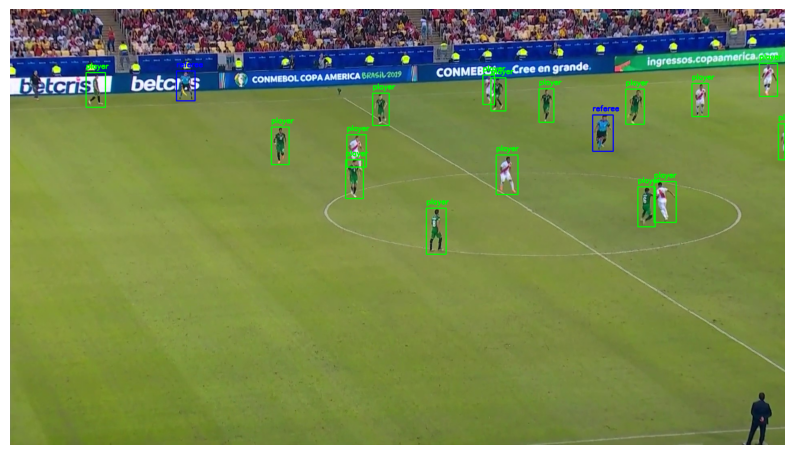

In [15]:
img = "dataset_engineering/active_learning/fine_tuning/train/images/20250710_145737_2e7ba5.jpg"
label = "dataset_engineering/active_learning/fine_tuning/train/labels/20250710_145737_2e7ba5.txt"

mostrar_imagen_etiquetada(img,label)


In [3]:
import os
imgs_path = "dataset_engineering/active_learning/fine_tuning/train/images"
labels_path= "dataset_engineering/active_learning/fine_tuning/train/labels"

imgs = os.listdir(imgs_path)

for img in imgs:
    mostrar_imagen_etiquetada(os.path.join(imgs_path,img),os.path.join(labels_path,os.path.splitext(img)[0]+".txt"))

NameError: name 'mostrar_imagen_etiquetada' is not defined